## Exercise 4.2: Interruptions and Outage Data for Statistical Benchmarking
For this exercise, we explore the collection and exploratory data analysis of outage data in order to develop statistical benchmarks for the relationship between weather and outages for a given region of interest. We will use real historical data from a UK distribution network operator as an example. 

First let's load the libraries in python for data processing and set some figure formatting.

In [25]:
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (12, 6)

### Data: 
The dataset provides detailed information about **UK Power Networks'** unplanned fault reporting to their regulator, the Office of Gas and Electricity Markets (Ofgem) via the Interruptions Incentive Scheme (IIS). This data is made publicly available from UKPN via their open data portal.

It includes key characteristics such as:
•	Date/time fault start/end
•	Number of customers affected
•	Restoration stages
•	Cause and main equipment involved
•	Status of fault in terms of its exclusion from the IIS scheme due to it being a one-off /severe weather fault
•	The upstream primary substation to the fault

In order to download the data you will need to register for a free account on UKPN’s Open Data Portal. 
Download the data here: https://ukpowernetworks.opendatasoft.com/explore/assets/ukpn-iis/ 

More information about the IIS can be found on Ofgem's website or this document: RIIO-ED2 Regulatory Instructions and Guidance – Interruptions[https://www.ofgem.gov.uk/sites/default/files/2023-10/RIIO-ED2%20-%20Annex%20F%20Interruptions%20v1.1.pdf]


### Exploratory Data Analysis: 
Download the data from the Portal in Excel and include the filename/path below. 

**Note:** The full outage data file is quite large (300,000 rows and 20 columns) and may take several minutes to read in excel - (3-5 minutes on my laptop). There are faster ways to load the data (e.g. using parquet) that also carry the added benefit of retaining the correct variable datatypes. However, this requires installation of additional python libraries such as pyarrow to work with. 

In [26]:
outage_data_filepath = "ukpn-iis.xlsx"
df = pd.read_excel(outage_data_filepath)

In [27]:
outages = df.copy(deep=True)
outages["Start_Date"] = pd.to_datetime(pd.to_datetime(df["Start Date and Time"],utc=True).dt.date)
outages.dtypes

Incident Reference                                                  str
Restoration Stage                                                 int64
Start Date and Time                                                 str
End Date and Time                                                   str
Number of Customers Restored                                      int64
Re-interruption Stage                                               str
MEI code                                                            str
Cause Code                                                          str
Continued Cause Code                                            float64
Damage to the Network                                             int64
Exceptional Event?                                                  str
incident_count                                                    int64
Whether or not this incident was excluded from the IIS              str
ee_coding_only_for_additional_incidents                         

You can then group the number of outages by day and plot the time series as shown in Figure 4.2.1. 

In [28]:
outage_daily = outages.groupby("Start_Date").agg(
        incidents=("incident_count", "sum"),
        customers_restored=("Number of Customers Restored", "sum")
    )
outage_daily_df = outage_daily.reset_index()

In [29]:
outage_daily_df

,Start_Date,incidents,customers_restored
0,2021-04-01,110,8096
1,2021-04-02,88,15291
2,2021-04-03,85,3491
3,2021-04-04,54,2024
4,2021-04-05,74,2166
...,...,...,...
1457,2025-03-28,49,2618
1458,2025-03-29,60,3514
1459,2025-03-30,53,1579
1460,2025-03-31,91,4139


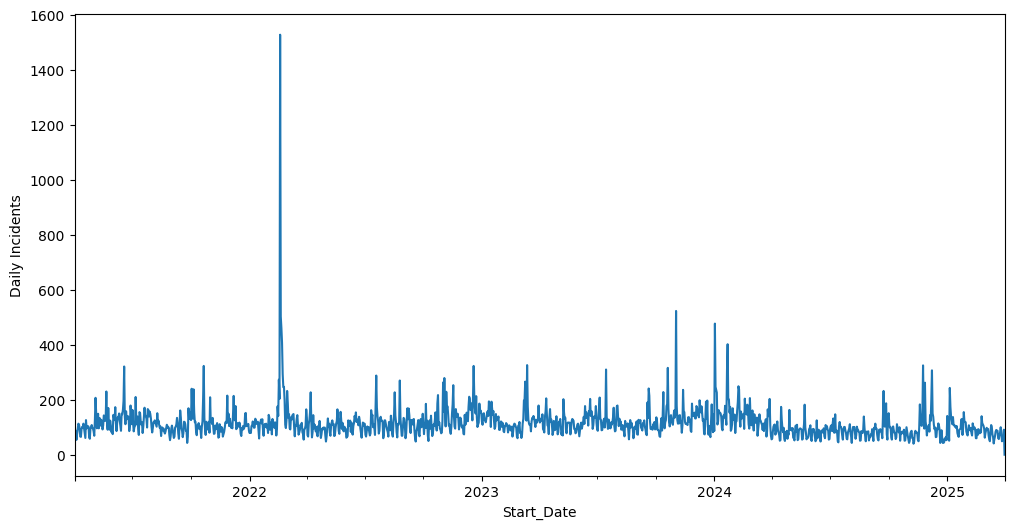

In [30]:
outage_daily.incidents.plot()
plt.ylabel('Daily Incidents')
plt.show()

### Activity:
Use this data and determine the answers to the following questions below. 
**Q4.2.1:** What is the total number of outages and time horizon covered?
**Q4.2.2:** What is the daily average number of outages?
**Q4.2.3:** What might be causing the spike observed in February 2022?

## Analysis of Faults and Meteorological Variables

Next we will explore the relationship between our meteorological parameters and our faults. First, let's reload the weather. Update the cell below with the filename and parameters you used in the prior example.

In [31]:
filename_weather = "open-meteo-52.20N0.17E14m.xlsx"
example_vars = [
        "temperature_2m_mean (°C)",
        "temperature_2m_max (°C)",
        "temperature_2m_min (°C)",
        "wind_speed_10m_max (km/h)",
        "wind_gusts_10m_max (km/h)",
        "precipitation_sum (mm)"
    ]

Next we load the weather in the data-frame

In [32]:
def load_open_meteo_excel(path, weather_vars):
    df = pd.read_excel(path, header = 3) # The header is because the first two rows are metadata
    df = df.rename(columns={"time": "date"})
    df["date"] = pd.to_datetime(df["date"], origin="unix", unit="D", errors="coerce")
    numeric_cols = weather_vars
    df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors="coerce")
    return df [["date"] + numeric_cols]

weather = load_open_meteo_excel(filename_weather,example_vars)

Once we have the weather and the incident data we can merge them into a single dataframe.

In [33]:
def merge_weather_outages(weather_df, outage_daily_df):
    merged = weather_df.merge(outage_daily_df, left_on="date", right_on="Start_Date", how="right") # Note this currently ignores days with 0 incidents
    merged[["incidents", "customers_restored"]] = merged[["incidents", "customers_restored"]].fillna(0)
    return merged
wf = merge_weather_outages(weather,outage_daily_df)

In [34]:
wf

,date,temperature_2m_mean (°C),temperature_2m_max (°C),temperature_2m_min (°C),wind_speed_10m_max (km/h),wind_gusts_10m_max (km/h),precipitation_sum (mm),Start_Date,incidents,customers_restored
0,2021-04-01,8.6,12.1,5.6,22.1,42.1,0.0,2021-04-01,110,8096
1,2021-04-02,6.3,8.5,4.3,23.9,44.6,0.0,2021-04-02,88,15291
2,2021-04-03,6.4,7.9,4.9,24.5,45.7,0.0,2021-04-03,85,3491
3,2021-04-04,7.4,14.3,1.2,19.1,34.6,0.0,2021-04-04,54,2024
4,2021-04-05,5.1,8.1,1.9,32.6,62.3,0.6,2021-04-05,74,2166
...,...,...,...,...,...,...,...,...,...,...
1457,2025-03-28,9.5,12.6,5.8,19.2,40.7,0.9,2025-03-28,49,2618
1458,2025-03-29,7.8,12.1,2.5,24.7,47.9,0.0,2025-03-29,60,3514
1459,2025-03-30,11.1,14.5,7.2,28.9,58.7,0.0,2025-03-30,53,1579
1460,2025-03-31,8.7,14.7,2.8,15.1,28.1,0.0,2025-03-31,91,4139


Now lets create a function to plot the relationship between a given meteorological variable and the number of incidents recorded on the network.

In [35]:
def plot_weather_vs_outages(df, weather_var, weather_unit,avg=False):
    plt.scatter(df[weather_var], df["incidents"], alpha=0.4)
    plt.xlabel(weather_unit)
    plt.ylabel("Number of Power Outages")
    if(avg):
        df["weather_round"]= df[weather_var].round(0)
        df2 = df.groupby("weather_round").mean().reset_index()
        plt.scatter(df2.weather_round,df2.incidents,color='k')
    plt.show() 

Using that function we can now calculate the 'statistical benchmark' metric from the draft IEEE Distribution Resiliency Guide

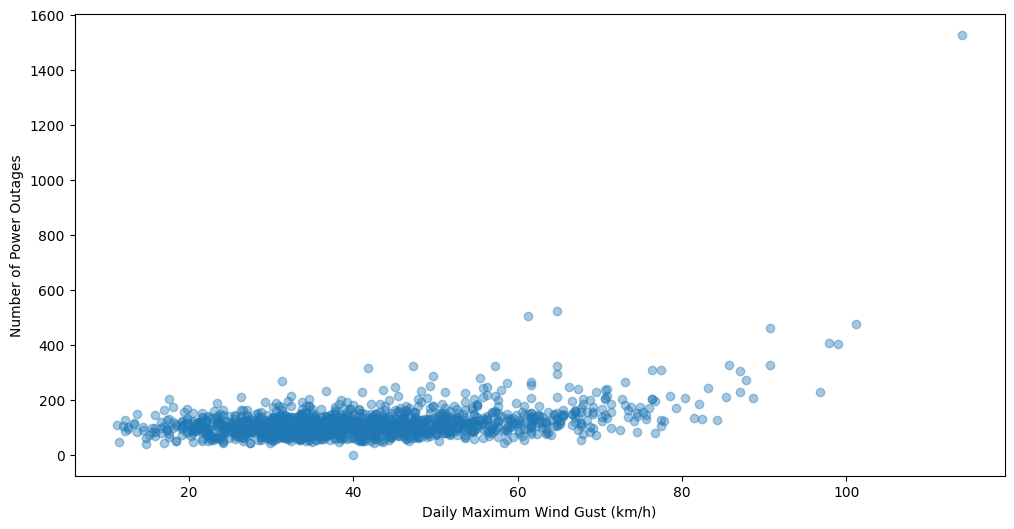

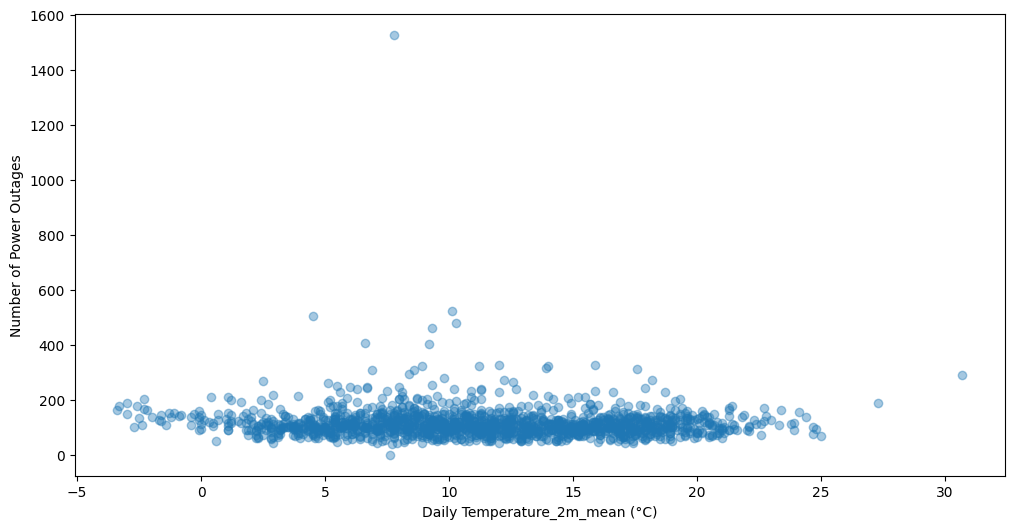

In [36]:
plot_weather_vs_outages(wf,"wind_gusts_10m_max (km/h)","Daily Maximum Wind Gust (km/h)")
plot_weather_vs_outages(wf,"temperature_2m_mean (°C)","Daily Temperature_2m_mean (°C)")

Now lets only look at wind related faults. The cause code data can be obtained from the Ofgem document here: RIIO-ED2 Regulatory Instructions and Guidance – Interruptions[https://www.ofgem.gov.uk/sites/default/files/2023-10/RIIO-ED2%20-%20Annex%20F%20Interruptions%20v1.1.pdf]

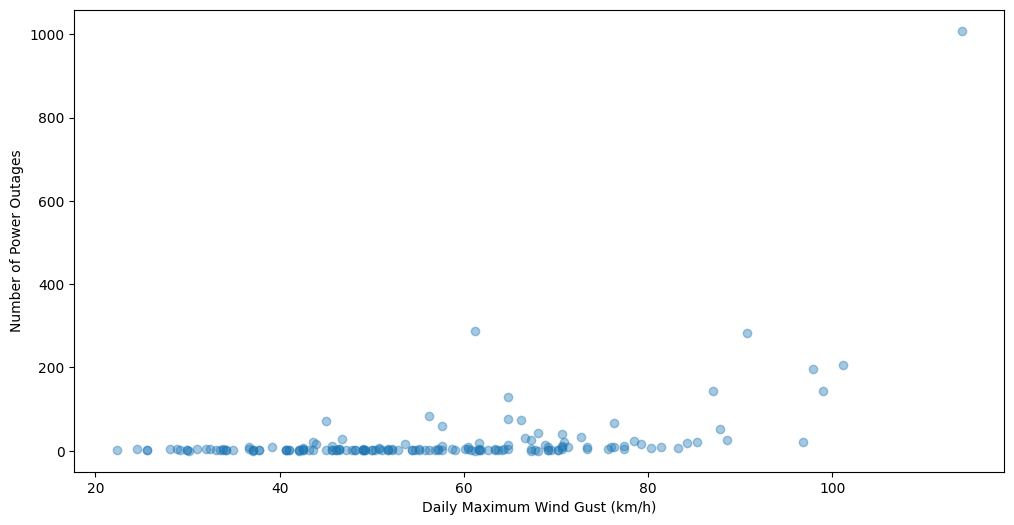

In [37]:
def filter_outages(df,cause_code):
    return df[df["Cause Code"].isin(cause_code)]

def daily_cause(df,weather,cause_code):
    df2 = filter_outages(df,cause_code)
    df2 = df2.groupby("Start_Date").agg(
        incidents=("incident_count", "sum"),
        customers_restored=("Number of Customers Restored", "sum")
    ).reset_index()
    wf = merge_weather_outages(weather,df2)
    return wf

wind_faults = daily_cause(outages,weather,["06"])
plot_weather_vs_outages(wind_faults,"wind_gusts_10m_max (km/h)","Daily Maximum Wind Gust (km/h)")

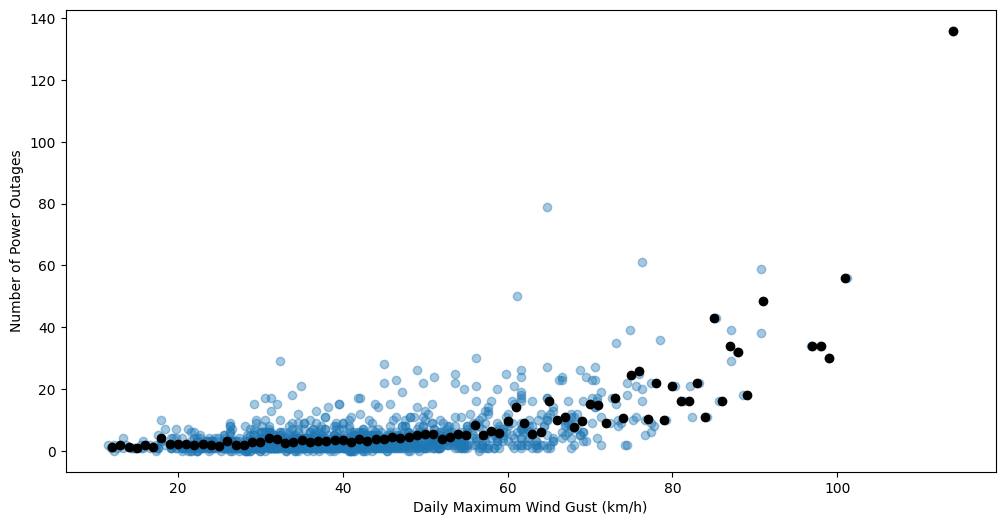

In [38]:
wind_faults = daily_cause(outages,weather,["23","24","25"])
plot_weather_vs_outages(wind_faults,"wind_gusts_10m_max (km/h)","Daily Maximum Wind Gust (km/h)",avg=True)